Task 2: Dataset Exploration
Number of classes: 4

Images per class:
 class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64


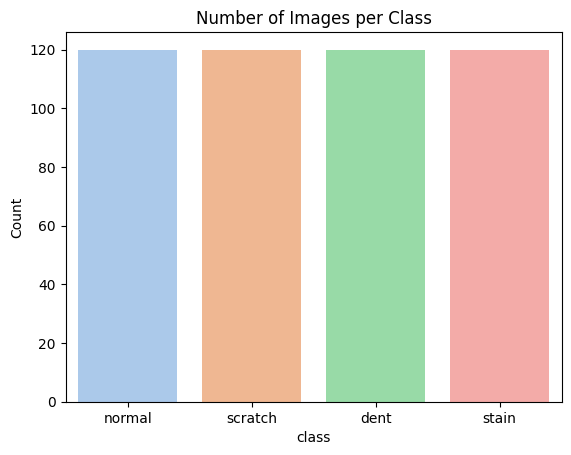

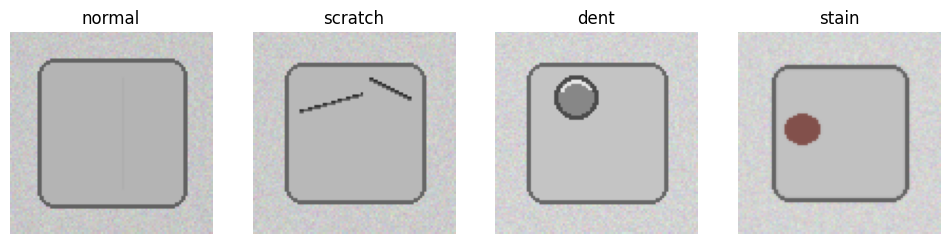

Image dimensions: (96, 96)


In [12]:
print ("Task 2: Dataset Exploration")
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from google.colab import files

# Check if labels.csv exists, if not, prompt for upload
import os
if not os.path.exists("labels.csv"):
    print("labels.csv not found. Please upload the file.")
    uploaded = files.upload()
    if "labels.csv" not in uploaded:
        raise FileNotFoundError("labels.csv was not uploaded. Please upload the correct file.")

# Step 2: Load the labels file
df = pd.read_csv("labels.csv")

# As I have used Google Colab for creating this python file, the image folder path is connected to my drive. this needs to be adjusted while running the code in a new drive.
base_image_path = '/content/drive/MyDrive/Colab Notebooks/Assignmnt 5 part 2/'
df['filename'] = df['filename'].apply(lambda x: base_image_path + x)

# Step 3: Number of classes
num_classes = df['class'].nunique()
print("Number of classes:", num_classes)

# Step 4: Number of images per class
class_counts = df['class'].value_counts()
print("\nImages per class:\n", class_counts)

# Step 5: Plot class distribution
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette="pastel", legend=False)
plt.title("Number of Images per Class")
plt.ylabel("Count")
plt.show()

# Step 6: Sample images from each class
sample_paths = []
for c in df['class'].unique():
    sample_paths.append(df[df['class']==c]['filename'].iloc[0])

# Display sample images
fig, axes = plt.subplots(1, len(sample_paths), figsize=(12,4))
for i, path in enumerate(sample_paths):
    img = Image.open(path)
    axes[i].imshow(img)
    axes[i].set_title(df['class'].unique()[i])
    axes[i].axis("off")
plt.show()

# Step 7: Image dimensions (check first image)
img = Image.open(df['filename'].iloc[0])
print("Image dimensions:", img.size)  # (width, height)

In [6]:
print ("Task 3: Image Preprocessing")

# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from PIL import Image

# Step 2: Load the labels file
df = pd.read_csv("labels.csv")

# As I have used Google Collab for creating this python file, the image folder path is connected to my drive. this needs to be adjusted while running the code in a new drive.
base_image_path = '/content/drive/MyDrive/Colab Notebooks/Assignmnt 5 part 2/'
df['filename'] = df['filename'].apply(lambda x: base_image_path + x)

# Step 3: Define image size (resize all images to same size)
IMG_SIZE = (128, 128)  # small but clear

# Function to load and preprocess images
def load_and_preprocess(path):
    img = Image.open(path).resize(IMG_SIZE)   # resize
    img = np.array(img) / 255.0              # normalize (0-1)
    return img

# Step 4: Load all images
X = np.array([load_and_preprocess(fname) for fname in df['filename']])
y = df['class'].values

print("Shape of X:", X.shape)  # (num_images, 128, 128, 3)

# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Step 6: Data Augmentation (make training images more varied)
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

datagen.fit(X_train)

Task 3: Image Preprocessing
Shape of X: (480, 128, 128, 3)
Training samples: 384
Testing samples: 96


In [8]:
print ("Task 4 CNN Model creation")

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input # Import Input layer

# Step 1: Build the CNN
model = Sequential([
    Input(shape=(128,128,3)), # Explicit Input layer
    Conv2D(32, (3,3), activation='relu'),  # Convolution (input_shape removed here)
    MaxPooling2D(pool_size=(2,2)),                                  # Pooling
    Flatten(),                                                      # Flatten
    Dense(64, activation='relu'),                                   # Dense
    Dense(4, activation='softmax')                                  # Output
])

# Step 2: Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Step 3: Summary
model.summary()

Task 4 CNN Model creation


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 127008)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     8,128,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,129,732 (31.01 MB)

 Trainable params: 8,129,732 (31.01 MB)

 Non-trainable params: 0 (0.00 B)

Task 5: Model Training
Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 477ms/step - accuracy: 0.6562 - loss: 0.9940 - val_accuracy: 0.5729 - val_loss: 1.0177
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 524ms/step - accuracy: 0.6719 - loss: 0.9640 - val_accuracy: 0.5833 - val_loss: 0.9978
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 447ms/step - accuracy: 0.6953 - loss: 0.9365 - val_accuracy: 0.6354 - val_loss: 0.9912
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 482ms/step - accuracy: 0.7005 - loss: 0.8974 - val_accuracy: 0.6354 - val_loss: 0.9113
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 555ms/step - accuracy: 0.6771 - loss: 0.8900 - val_accuracy: 0.6042 - val_loss: 0.8797
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 441ms/step - accuracy: 0.7604 - loss: 0.8161 - val_accuracy: 0.7396 - val_loss: 0.8703
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 417ms/step - accuracy: 0.7839 - loss: 0.7713 - val_accuracy: 0.7604 - val_loss: 0.8231
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 530ms/step - accuracy: 0.7734 - loss

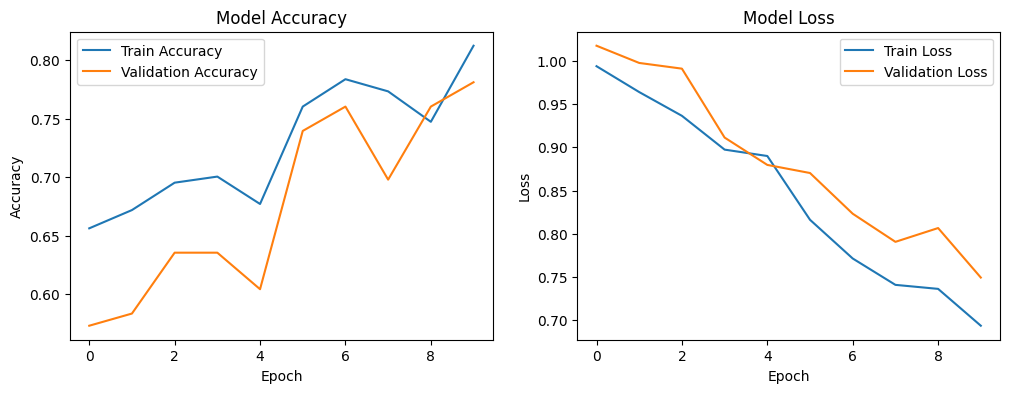

Test Accuracy: 0.78125
Test Loss: 0.749180257320404
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


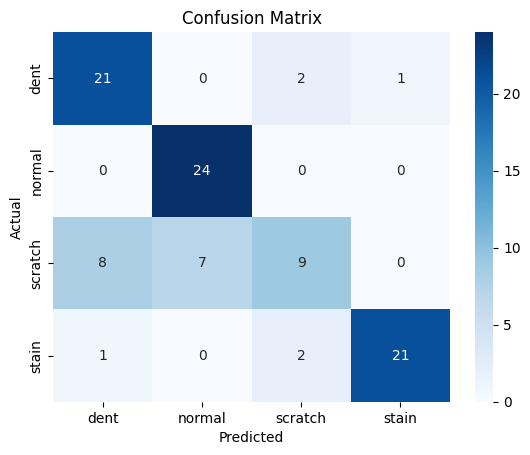


Classification Report:
               precision    recall  f1-score   support

        dent       0.70      0.88      0.78        24
      normal       0.77      1.00      0.87        24
     scratch       0.69      0.38      0.49        24
       stain       0.95      0.88      0.91        24

    accuracy                           0.78        96
   macro avg       0.78      0.78      0.76        96
weighted avg       0.78      0.78      0.76        96



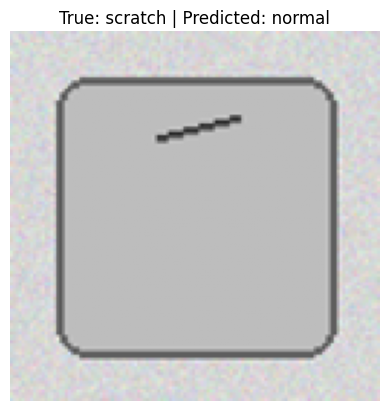

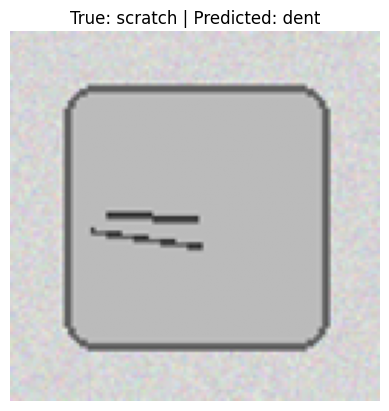

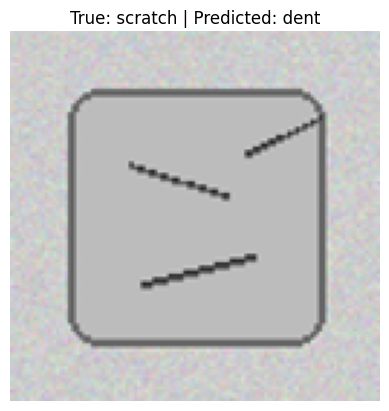

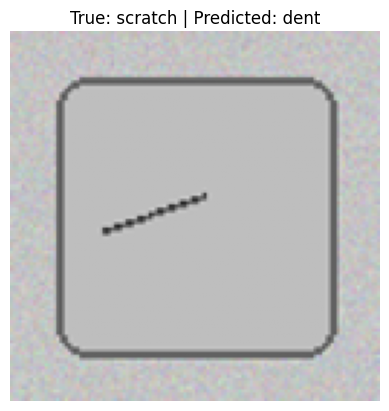

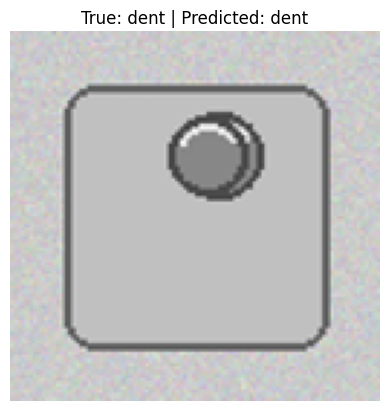

In [11]:
print ("Task 5: Model Training")

# --- Start of fix for 'Cast string to float is not supported' error ---
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform y_train to get integer labels
y_train_encoded = label_encoder.fit_transform(y_train)
# Transform y_test using the same encoder
y_test_encoded = label_encoder.transform(y_test)

# Store original class names for plotting and reporting
class_names = label_encoder.classes_
# --- End of fix ---

# Step 1: Train the model
history = model.fit(
    X_train, y_train_encoded, # Use encoded labels for training
    validation_data=(X_test, y_test_encoded), # Use encoded labels for validation
    epochs=10,
    batch_size=32,
    verbose=1
)

# Step 2: Plot training accuracy and loss
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Step 3: Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test_encoded, verbose=0) # Use encoded labels for evaluation
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

# Step 4: Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
# numpy is already imported for the fix

y_pred_encoded = np.argmax(model.predict(X_test), axis=1) # Predictions will be integer indices

cm = confusion_matrix(y_test_encoded, y_pred_encoded) # Use encoded labels for confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, # Use original class names for display
            yticklabels=class_names) # Use original class names for display
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification report expects actual labels and predictions to be consistent
print("\nClassification Report:\n", classification_report(y_test_encoded, y_pred_encoded, target_names=class_names))

# Step 5: Sample predictions
for i in range(5):
    plt.imshow(X_test[i])
    # Decode predicted and true labels back to original strings for display
    true_label_str = label_encoder.inverse_transform([y_test_encoded[i]])[0]
    predicted_label_str = label_encoder.inverse_transform([y_pred_encoded[i]])[0]
    plt.title(f"True: {true_label_str} | Predicted: {predicted_label_str}")
    plt.axis("off")
    plt.show()